In [41]:
import pandas as pd

data = pd.read_csv("C:/Users/DELL/Downloads/bank_dataset (2).csv")
data.head()

,Unnamed: 0,Close,Close.1,Close.2,High,High.1,High.2,Low,Low.1,Low.2,...,"('Close', 'JPM')","('High', 'JPM')","('Low', 'JPM')","('Open', 'JPM')","('Volume', 'JPM')","('Close', 'JPM').1","('High', 'JPM').1","('Low', 'JPM').1","('Open', 'JPM').1","('Volume', 'JPM').1"
0,Ticker,BAC,JPM,WFC,BAC,JPM,WFC,BAC,JPM,WFC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-04-01,35.81013488769531,190.58596801757812,55.0481071472168,36.60230814354954,192.5019825513943,55.306100793655006,35.733778908847285,190.231510006592,54.713669318844644,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-04-02,35.60015869140625,190.5093231201172,54.79966735839844,35.86740096979999,191.39068803965642,55.420763580688465,35.46653937263607,189.7620786314202,54.64678263915063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-04-03,35.733768463134766,189.97283935546875,54.58945846557617,36.28733822540279,191.1799232200789,55.38254688485404,35.57151751679218,189.39802916201796,54.32190744703387,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
print(data.columns)
print(data.head())

Index(['Unnamed: 0', 'Close', 'Close.1', 'Close.2', 'High', 'High.1', 'High.2',
       'Low', 'Low.1', 'Low.2', 'Open', 'Open.1', 'Open.2', 'Volume',
       'Volume.1', 'Volume.2', '('Close', 'JPM')', '('High', 'JPM')',
       '('Low', 'JPM')', '('Open', 'JPM')', '('Volume', 'JPM')',
       '('Close', 'JPM').1', '('High', 'JPM').1', '('Low', 'JPM').1',
       '('Open', 'JPM').1', '('Volume', 'JPM').1'],
      dtype='object')
   Unnamed: 0               Close             Close.1            Close.2  \
0      Ticker                 BAC                 JPM                WFC   
1        Date                 NaN                 NaN                NaN   
2  2024-04-01   35.81013488769531  190.58596801757812   55.0481071472168   
3  2024-04-02   35.60015869140625   190.5093231201172  54.79966735839844   
4  2024-04-03  35.733768463134766  189.97283935546875  54.58945846557617   

                High              High.1              High.2  \
0                BAC                 JPM          

In [43]:
print(data.columns)

Index(['Unnamed: 0', 'Close', 'Close.1', 'Close.2', 'High', 'High.1', 'High.2',
       'Low', 'Low.1', 'Low.2', 'Open', 'Open.1', 'Open.2', 'Volume',
       'Volume.1', 'Volume.2', '('Close', 'JPM')', '('High', 'JPM')',
       '('Low', 'JPM')', '('Open', 'JPM')', '('Volume', 'JPM')',
       '('Close', 'JPM').1', '('High', 'JPM').1', '('Low', 'JPM').1',
       '('Open', 'JPM').1', '('Volume', 'JPM').1'],
      dtype='object')


In [44]:
data = pd.read_csv("C:/Users/DELL/Downloads/bank_dataset (2).csv", header=0)

In [45]:
data = data.iloc[2:]   # supprimer les 2 premières lignes

In [46]:
data = data.rename(columns={"Unnamed: 0": "Date"})

In [47]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data = data.set_index('Date')

In [48]:
#creation de la nouvelle data correcte
data_jpm = pd.DataFrame()

data_jpm['Close'] = data['Close.1']
data_jpm['High'] = data['High.1']
data_jpm['Low'] = data['Low.1']
data_jpm['Volume'] = data['Volume.1']

In [49]:
#nettoyage de la nouvelle data
data_jpm = data_jpm.astype(float)
data_jpm = data_jpm.dropna()

In [50]:
data_jpm.head()

,Close,High,Low,Volume
Date,,,,
2024-04-01,190.585968,192.501983,190.231510,7309000.0
2024-04-02,190.509323,191.390688,189.762079,7014700.0
2024-04-03,189.972839,191.179923,189.398029,9353400.0
2024-04-04,188.527451,192.410739,188.431100,9243800.0
2024-04-05,190.261917,190.907524,188.007107,6532300.0


In [51]:
#Calculer le Return (rendement quotidien)
data_jpm['Return'] = data_jpm['Close'].pct_change()

In [52]:
#calculer la volatilité
data_jpm['Volatility'] = data_jpm['Return'].rolling(5).std()

In [53]:
#Calculer les Moyennes mobiles
data_jpm['MA_5'] = data_jpm['Close'].rolling(5).mean()
data_jpm['MA_10'] = data_jpm['Close'].rolling(10).mean()

In [54]:
#changement de volume
data_jpm['Volume_Change'] = data_jpm['Volume'].pct_change()

In [55]:
#High-Low Spread
data_jpm['HL_Spread'] = data_jpm['High'] - data_jpm['Low']

In [56]:
#Supprime les premières lignes qui n’ont pas de retour ou de volatilité calculée
data_jpm = data_jpm.dropna()

In [57]:
data_jpm.head()

,Close,High,Low,Volume,Return,Volatility,MA_5,MA_10,Volume_Change,HL_Spread
Date,,,,,,,,,,
2024-04-12,176.135590,182.052065,175.894691,31532300.0,-0.064678,0.028312,186.806464,188.388982,2.110400,6.157374
2024-04-15,176.231964,180.635602,175.567081,14766600.0,0.000547,0.027546,183.801974,186.953581,-0.531699,5.068521
2024-04-16,174.218048,176.492134,173.109905,16451800.0,-0.011428,0.027231,180.651013,185.324454,0.114122,3.382229
2024-04-17,173.524277,175.779087,172.676308,9017100.0,-0.003982,0.027650,177.685071,183.679597,-0.451908,3.102779
2024-04-18,174.651672,176.684859,173.418271,9557700.0,0.006497,0.028745,174.952310,182.292020,0.059953,3.266588


In [58]:
#les bibliothheques
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [59]:
#Sélectionner les features pour l’anomalie
features = ['Return', 'Volatility', 'Volume_Change', 'HL_Spread']
X = data_jpm[features]

In [60]:
#Normaliser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
#Créer et entraîner le modèle Isolation Forest
model = IsolationForest(contamination=0.01, random_state=42)
data_jpm['Anomaly'] = model.fit_predict(X_scaled)

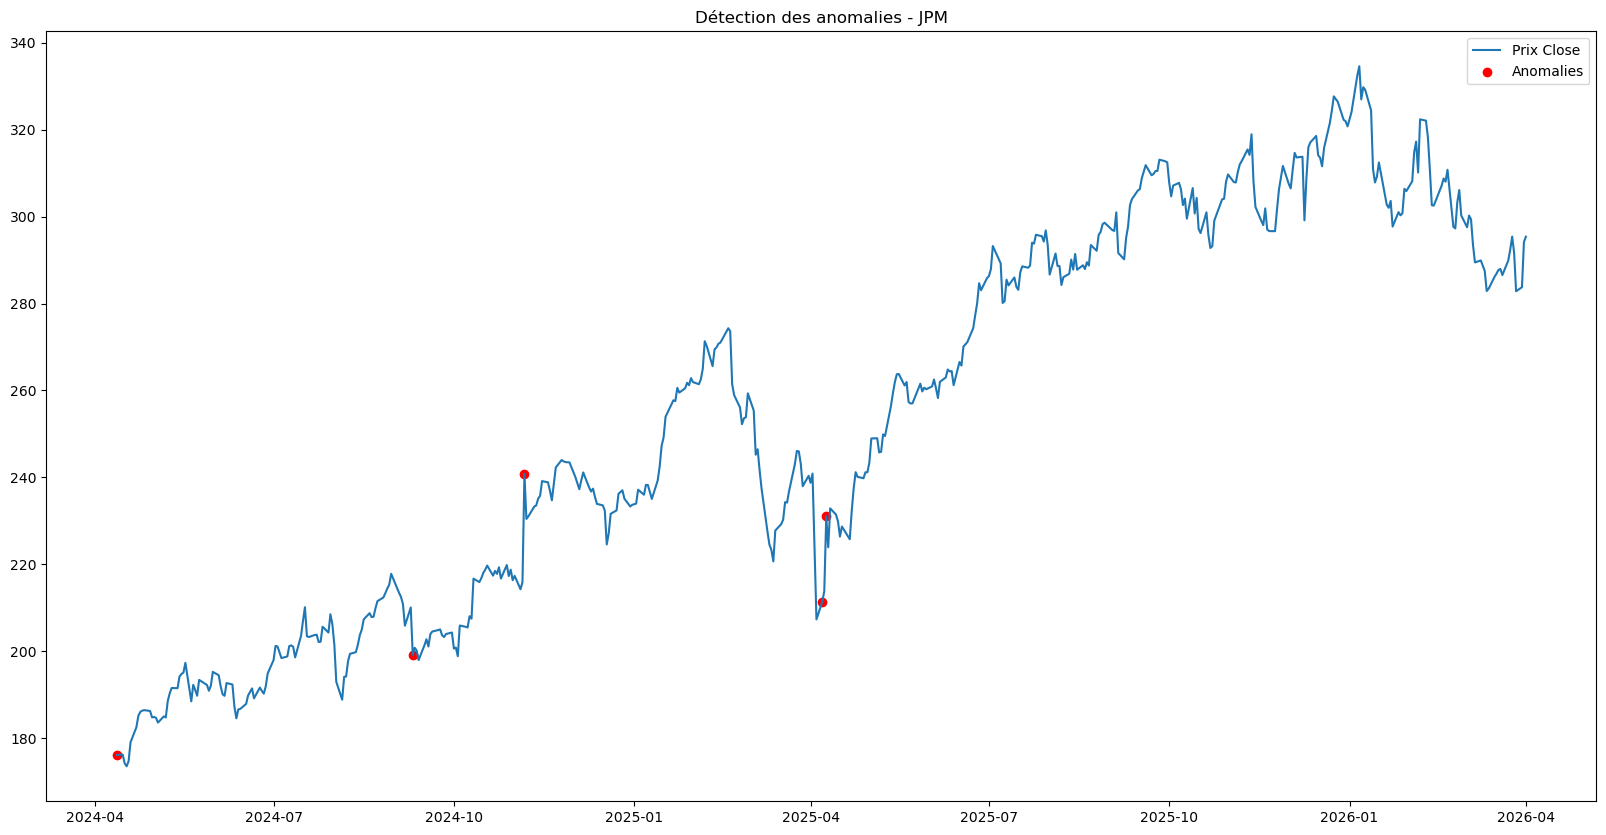

In [62]:
#Visualiser les anomalies
plt.figure(figsize=(20,10))
plt.plot(data_jpm['Close'], label='Prix Close')

# Marquer les anomalies en rouge
anomalies = data_jpm[data_jpm['Anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['Close'], color='red', label='Anomalies')

plt.legend()
plt.title("Détection des anomalies - JPM")
plt.show()

In [63]:
#interpretation:
#Les anomalies d'avril 2025 sont les plus marquantes : une chute brutale puis un rebond rapide, probablement liés à un événement de marché majeur (résultats trimestriels, annonce macro, etc. — coïncide avec les turbulences liées aux tarifs douaniers de Trump).
#Le pic de novembre 2024 correspond à un saut soudain, possiblement lié à l'élection américaine et l'anticipation de politiques favorables aux banques.

In [64]:
#Extraire les anomalies
anomalies = data_jpm[data_jpm['Anomaly'] == -1]
anomalies.head()

,Close,High,Low,Volume,Return,Volatility,MA_5,MA_10,Volume_Change,HL_Spread,Anomaly
Date,,,,,,,,,,,
2024-04-12,176.135590,182.052065,175.894691,31532300.0,-0.064678,0.028312,186.806464,188.388982,2.110400,6.157374,-1
2024-09-10,199.174225,211.847893,194.378001,28406900.0,-0.051889,0.026688,207.698920,211.283012,2.179248,17.469892,-1
2024-11-06,240.851974,241.768357,228.870799,23987800.0,0.115445,0.053921,220.943143,219.667035,3.283000,12.897558,-1
2025-04-07,211.425644,218.928672,199.318264,22914400.0,0.019783,0.044630,224.497961,233.603645,-0.156650,19.610408,-1
2025-04-09,231.045898,234.141759,208.033990,24022400.0,0.080555,0.065669,217.542426,228.883354,0.232822,26.107769,-1


In [65]:
#Nombre d'anomalie
len(anomalies)


5

In [66]:
#dates des anomalies 
anomalies.index

DatetimeIndex(['2024-04-12', '2024-09-10', '2024-11-06', '2025-04-07',
               '2025-04-09'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [67]:
#comparaison anomalies vs jours normaux
data_jpm.groupby('Anomaly').mean()

,Close,High,Low,Volume,Return,Volatility,MA_5,MA_10,Volume_Change,HL_Spread
Anomaly,,,,,,,,,,
-1,211.726666,217.747749,201.299149,2.617276e+07,0.019843,0.043844,211.497783,216.365206,1.529764,16.448600
1,254.902923,257.293911,252.371427,9.311666e+06,0.000849,0.013137,254.486066,253.924426,0.048095,4.922484


In [71]:
#analyse temporelle
data_jpm['Day'] = data_jpm.index.day_name()
data_jpm.groupby('Day')['Anomaly'].count()

Day
Friday       101
Monday        95
Thursday      95
Tuesday      103
Wednesday    100
Name: Anomaly, dtype: int64

In [72]:
#distance à la moyenne(Z-score)
data_jpm['Z_score'] = (data_jpm['Return'] - data_jpm['Return'].mean()) / data_jpm['Return'].std()

In [73]:
data_jpm.loc['2024-04-01':'2024-04-20']

,Close,High,Low,Volume,Return,Volatility,MA_5,MA_10,Volume_Change,HL_Spread,Anomaly,Day,Z_score
Date,,,,,,,,,,,,,
2024-04-12,176.135590,182.052065,175.894691,31532300.0,-0.064678,0.028312,186.806464,188.388982,2.110400,6.157374,-1,Friday,-4.081452
2024-04-15,176.231964,180.635602,175.567081,14766600.0,0.000547,0.027546,183.801974,186.953581,-0.531699,5.068521,1,Monday,-0.030674
2024-04-16,174.218048,176.492134,173.109905,16451800.0,-0.011428,0.027231,180.651013,185.324454,0.114122,3.382229,1,Tuesday,-0.774363
2024-04-17,173.524277,175.779087,172.676308,9017100.0,-0.003982,0.027650,177.685071,183.679597,-0.451908,3.102779,1,Wednesday,-0.311968
2024-04-18,174.651672,176.684859,173.418271,9557700.0,0.006497,0.028745,174.952310,182.292020,0.059953,3.266588,1,Thursday,0.338840
2024-04-19,179.036026,179.113115,174.805843,13402300.0,0.025103,0.013812,175.532397,181.169431,0.402252,4.307273,1,Friday,1.494378


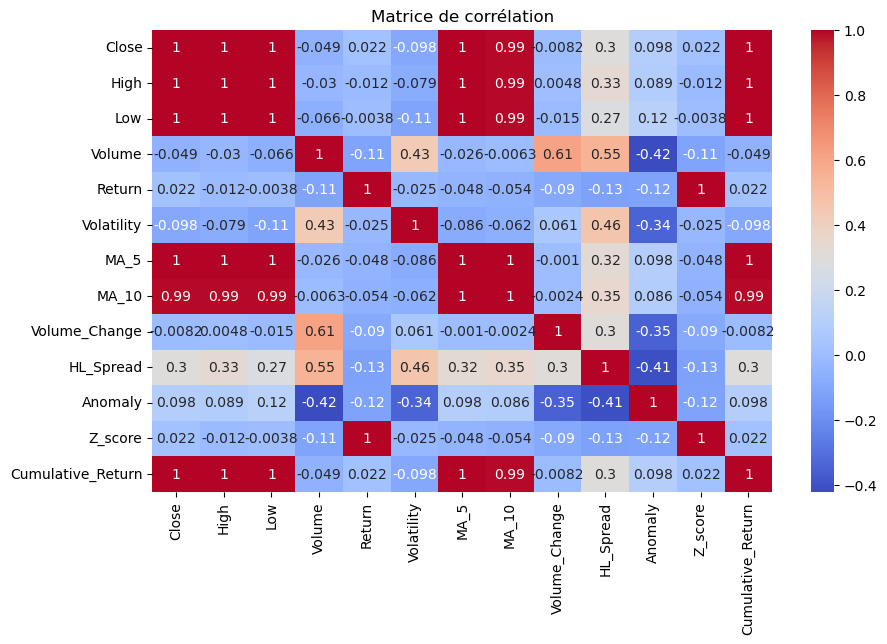

In [85]:
#l'analyse de corrélation
numeric_data = data_jpm.select_dtypes(include=['float64', 'int64'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [86]:
data_jpm['Cumulative_Return'] = (1 + data_jpm['Return']).cumprod()

In [87]:
data_jpm['Risk_Level'] = 'Low'
data_jpm.loc[data_jpm['Anomaly'] == -1, 'Risk_Level'] = 'High'

In [88]:
data_jpm['Risk_Level'] = 'Low'

data_jpm.loc[
    (data_jpm['Volatility'] > data_jpm['Volatility'].mean()), 
    'Risk_Level'
] = 'Medium'

data_jpm.loc[data_jpm['Anomaly'] == -1, 'Risk_Level'] = 'High'

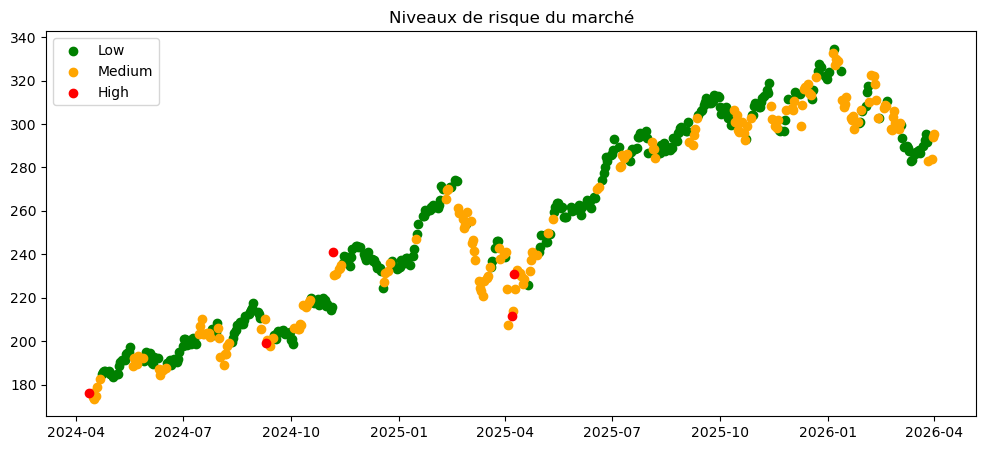

In [89]:
import matplotlib.pyplot as plt

colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

plt.figure(figsize=(12,5))

for level in colors:
    subset = data_jpm[data_jpm['Risk_Level'] == level]
    plt.scatter(subset.index, subset['Close'], 
                c=colors[level], label=level)

plt.legend()
plt.title("Niveaux de risque du marché")
plt.show()